**Musae** — MUon Scattering and Absorption tomography simulation infrastructurE
Copyright (C) 2026 Musae developers

This program is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.

This program is distributed in the hope that it will be useful,
but WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the
GNU General Public License for more details.

You should have received a copy of the GNU General Public License
along with this program. If not, see <https://www.gnu.org/licenses/>.

In [1]:
import numpy as np
import pandas as pd
import scipy as scp
import numba
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
from pathlib import Path
import os
import json
import laspy
import trimesh
import plotly.graph_objs as go
import plotly.io as pio
import plotly.offline as pyo
from matplotlib.colors import LogNorm
import math
from plotly.colors import sample_colorscale
from tqdm import tqdm
import shutil
from PIL import Image
import kaleido
import requests
import math
import imageio.v2 as imageio
import pyvista as pv
from matplotlib.ticker import ScalarFormatter
%matplotlib ipympl


In [2]:
def create_custom_3d_axis(
    axis_type='x',         # x/y/z axis
    range_lim=(0, 1),      # Axis coordinate range
    ticks=None,            # Tick positions (numeric list)
    ticklabels=None,       # Tick labels (string list)
    title='Axis Title',    # Axis title
    axis_color='black',    # Axis line color
    tick_color='black',    # Tick color
    label_color='black',   # Label color
    title_color='black',   # Title color
    label_font_size=12,    # Label font size
    title_font_size=14,    # Title font size
    tick_length=0.05,      # Tick line length (relative proportion)
    title_offset=0.1,      # Title offset (relative proportion)
    title_shift=(0, 0, 0), # Title offset (x, y, z)
    tick_witdth=1,         # Tick line width
    auto_ticknum=5,        # Number of ticks (used when ticks is None and tick_interval is None)
    tick_interval=None,    # Tick interval (e.g., 10, 20; used with priority when ticks is None)
    label_shift=None,
    line_width=2,          # Axis line width
    line_offset=(0, 0, 0), # Axis line offset
    label_font_family=None,   # Tick label font (e.g., 'Arial')
    label_font_style=None,    # Tick label style (e.g., 'italic')
    label_font_weight=None,   # Tick label weight (e.g., 'bold')
    title_font_family=None,   # Title font
    title_font_style=None,    # Title font style
    title_font_weight=None    # Title font weight
):
    components = []
    x0, y0, z0 = (0 + line_offset[0], 0 + line_offset[1], 0 + line_offset[2])  # Origin position

    # Determine label offset
    if label_shift is None:
        if axis_type == 'x':
            label_shift = (0, -2, 0)
        elif axis_type == 'y':
            label_shift = (-2, 0, 0)
        elif axis_type == 'z':
            label_shift = (0, -2, 0)
    else:
        assert len(label_shift) == 3, "label_shift must be a 3-element tuple"

    dx = label_shift[0] * tick_length
    dy = label_shift[1] * tick_length
    dz = label_shift[2] * tick_length

    # Auto-generate ticks
    if ticks is None:
        if tick_interval is not None:
            tick_interval = float(tick_interval)
            start = math.ceil(range_lim[0] / tick_interval) * tick_interval
            end = math.floor(range_lim[1] / tick_interval) * tick_interval
            if start <= end:
                ticks = np.arange(start, end + 1e-9 * tick_interval, tick_interval)
            else:
                ticks = np.array([])
        else:
            ticks = np.linspace(range_lim[0], range_lim[1], auto_ticknum)
    else:
        ticks = np.asarray(ticks, dtype=np.float64)

    # Auto-generate labels
    if ticklabels is None:
        all_tick_integer = all(t.is_integer() for t in ticks)
        if all_tick_integer:
            ticklabels = [f"{int(t)}" for t in ticks]
        else:
            ticklabels = [f"{t:.1f}" for t in ticks]
    else:
        if len(ticklabels) != len(ticks):
            raise ValueError("Length of ticklabels must match ticks")

    # Draw axis line based on axis type
    if axis_type.lower() == 'x':
        axis_line = go.Scatter3d(
            x=[range_lim[0], range_lim[1]], y=[y0, y0], z=[z0, z0],
            mode='lines', line=dict(color=axis_color, width=line_width),
            showlegend=False
        )
        title_pos = [range_lim[1] + title_offset * (range_lim[1]-range_lim[0]) + title_shift[0], 
                     y0 + title_shift[1], z0 + title_shift[2]]
    elif axis_type.lower() == 'y':
        axis_line = go.Scatter3d(
            x=[x0, x0], y=[range_lim[0], range_lim[1]], z=[z0, z0],
            mode='lines', line=dict(color=axis_color, width=line_width),
            showlegend=False
        )
        title_pos = [x0 + title_shift[0], 
                     range_lim[1] + title_offset * (range_lim[1]-range_lim[0]) + title_shift[1], 
                     z0 + title_shift[2]]
    elif axis_type.lower() == 'z':
        axis_line = go.Scatter3d(
            x=[x0, x0], y=[y0, y0], z=[range_lim[0], range_lim[1]],
            mode='lines', line=dict(color=axis_color, width=line_width),
            showlegend=False
        )
        title_pos = [x0 + title_shift[0], y0 + title_shift[1], 
                     range_lim[1] + title_offset * (range_lim[1]-range_lim[0]) + title_shift[2]]
    else:
        raise ValueError("axis_type must be 'x', 'y', or 'z'")
    components.append(axis_line)

    # Draw tick lines and labels
    for tick, label in zip(ticks, ticklabels):
        if axis_type == 'x':
            tick_start = [tick, y0 - tick_length, z0]
            tick_end = [tick, y0 + tick_length, z0]
            label_pos = [tick + dx, y0 + dy, z0 + dz]
        elif axis_type == 'y':
            tick_start = [x0 - tick_length, tick, z0]
            tick_end = [x0 + tick_length, tick, z0]
            label_pos = [x0 + dx, tick + dy, z0 + dz]
        elif axis_type == 'z':
            tick_start = [x0, y0 - tick_length, tick]
            tick_end = [x0, y0 + tick_length, tick]
            label_pos = [x0 + dx, y0 + dy, tick + dz]

        components.append(go.Scatter3d(
            x=[tick_start[0], tick_end[0]],
            y=[tick_start[1], tick_end[1]],
            z=[tick_start[2], tick_end[2]],
            mode='lines',
            line=dict(color=tick_color, width=tick_witdth),
            showlegend=False
        ))

        # Add tick label (set font style)
        components.append(go.Scatter3d(
            x=[label_pos[0]],
            y=[label_pos[1]],
            z=[label_pos[2]],
            mode='text',
            text=[label],
            textfont=dict(
                color=label_color,
                size=label_font_size,
                family=label_font_family,
                style=label_font_style,
                weight=label_font_weight
            ),
            showlegend=False
        ))

    # Add title (set font style)
    components.append(go.Scatter3d(
        x=[title_pos[0]],
        y=[title_pos[1]],
        z=[title_pos[2]],
        mode='text',
        text=[title],
        textfont=dict(
            color=title_color,
            size=title_font_size,
            family=title_font_family,
            style=title_font_style,
            weight=title_font_weight
        ),
        showlegend=False
    ))

    return components


def plot_precision_comparison(
    data,
    methods,
    thresholds,
    title="Precision Comparison",
    xlabel="Method",
    ylabel="Precision",
    figsize=(10, 6),
    bar_width=0.35,
    group_spacing=0.8,
    colors=None,
    font_family='Arial_Bold',
    title_fontsize=14,
    label_fontsize=12,
    tick_fontsize=10,
    legend_fontsize=10,
    legend_loc='upper left',
    ylim=None,
    show_values=True,
    value_fontsize=9,
    dpi=300
):
    """
    Draw grouped bar chart
    
    Parameters:
    -----------
    data : dict
        Format {threshold1: [val1, val2, val3, val4], threshold2: [...]}
    methods : list
        Method name list, e.g., ['L-BFGS-B', 'M-H (L-BFGS-B)', 'SART', 'M-H (SART)']
    thresholds : list
        Threshold labels, e.g., ['3.2 g/cm³', '5.1 g/cm³']
    colors : list or None
        Color for each method, default uses gradient blue
    show_values : bool
        Whether to show values on top of bars
    """
    
    if colors is None:
        # Baseline methods use gray, M-H methods highlighted with bright colors
        colors = ['#95A5A6', '#3498DB', '#E67E22', '#E74C3C']
    
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    n_methods = len(methods)
    n_thresholds = len(thresholds)
    
    # Center position of each threshold group
    group_centers = np.arange(n_thresholds) * (n_methods * bar_width + group_spacing)
    
    # Draw bars
    for i, (method, values) in enumerate(data.items()):
        x_positions = group_centers + i * bar_width
        bars = ax.bar(
            x_positions, 
            values, 
            bar_width, 
            label=method,
            color=colors[i % len(colors)],
            edgecolor='black',
            linewidth=0.8,
            alpha=0.9
        )
        
        # Show values on bars
        if show_values:
            for bar in bars:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width()/2., 
                    height + 0.01,  # Slight upward offset
                    f'{height*100:.0f}%',
                    ha='center', 
                    va='bottom',
                    fontdict=dict(color='black', size=value_fontsize, family=font_family)
                )
    
    # Set x-axis ticks (threshold labels)
    ax.set_xticks(group_centers + bar_width * (n_methods - 1) / 2)
    ax.set_xticklabels(thresholds,  fontdict=dict(size=tick_fontsize, family=font_family))
    
    # Set labels and title
    ax.set_xlabel(xlabel, fontdict=dict(size=label_fontsize, family=font_family))
    ax.set_ylabel(ylabel, fontdict=dict(size=label_fontsize, family=font_family))
    ax.set_title(title, fontdict=dict(size=title_fontsize, family=font_family, weight='bold'))
    
    # Set y-axis
    if ylim:
        ax.set_ylim(ylim)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.yaxis.set_tick_params(labelfontfamily=font_family)
    
    # Legend
    ax.legend(
        loc=legend_loc, 
        fontsize=legend_fontsize, 
        frameon=True,
        prop={'family': font_family},
        ncol=1  # Change to 2 columns if too many methods
    )
    
    # Grid
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    plt.tight_layout()
    return fig, ax

# Create a cone without bottom face
def create_cone_mesh(vertex, height, base_radius, num_points=30):
    base_center = [vertex[0], vertex[1], vertex[2] + height]  # Bottom face center offset along positive z-axis
    theta = np.linspace(0, 2*np.pi, num_points, endpoint=False)

    # Bottom face circumference coordinates
    x_circle = base_radius * np.cos(theta) + base_center[0]
    y_circle = base_radius * np.sin(theta) + base_center[1]
    z_circle = np.full(theta.shape, base_center[2])

    # Combine vertex and bottom face circumference point coordinates
    x = [vertex[0]] + list(x_circle)
    y = [vertex[1]] + list(y_circle)
    z = [vertex[2]] + list(z_circle)
    
    # Generate triangle patch vertex indices
    triangles = []
    for i in range(num_points):
        next_i = (i + 1) % num_points
        triangles.append((0, i + 1, next_i + 1))  # Vertex 0 connects to bottom face points i and next_i
    
    i = [tri[0] for tri in triangles]
    j = [tri[1] for tri in triangles]
    k = [tri[2] for tri in triangles]
    
    return x, y, z, i, j, k

def create_cuboids_traces(positions, sizes, colors, angle=0, name_prefix=None, 
                          add_edges=True, line_width=2, line_color='black', line_dash='solid'):
    """
    Generates a list of plotly.graph_objects.Mesh3d traces, one for each cuboid,
    with optional edge lines.

    Args:
        positions (list): A list of tuples [(x0, y0, z0), (x1, y1, z1), ...],
                          where (xi, yi, zi) is the bottom-front-left corner
                          of the i-th cuboid.
        sizes (list): A list of tuples [(lx0, ly0, lz0), (lx1, ly1, lz1), ...],
                      where (lxi, lyi, lzi) is the length, width, and height
                      of the i-th cuboid along the x, y, and z axes.
        colors (str or list): A single color string (e.g., 'blue', 'rgba(R,G,B,A)')
                              or a list of color strings, one for each cuboid.
        angle (float, optional): Rotation angle in degrees.
                                 Clockwise rotation from y-axis is positive.
        name_prefix (str, optional): A string prefix for trace names (e.g., 'Box').
                                     Traces will be named 'Box 1', 'Box 2', etc.
                                     Defaults to None.
        add_edges (bool, optional): Whether to add edge lines to the cuboids.
                                    Defaults to True.
        line_width (int, optional): Width of edge lines. Defaults to 2.
        line_color (str, optional): Color of edge lines. Defaults to 'black'.
        line_dash (str, optional): Line style ('solid', 'dot', 'dash', 'longdash',
                                  'dashdot', or 'longdashdot'). Defaults to 'solid'.

    Returns:
        list: A list of go.Mesh3d and go.Scatter3d traces for cuboids and their edges.

    Raises:
        ValueError: If the lengths of positions, sizes, or colors (if a list) do not match.
    """
    if not (len(positions) == len(sizes)):
        raise ValueError("Lengths of positions and sizes lists must be equal.")

    n_cuboids = len(positions)
    angle = np.deg2rad(angle)  # Convert angle to radians

    # Handle single color/opacity values vs. lists
    if isinstance(colors, str):
        colors = [colors] * n_cuboids
    elif len(colors) != n_cuboids:
        raise ValueError("Length of colors list must match the number of cuboids.")

    all_traces = []

    # Triangle faces definition
    triangles = [
        [0,1,2], [0,2,3],  # bottom face
        [4,5,6], [4,6,7],  # top face
        [0,1,5], [0,5,4],  # front face
        [1,2,6], [1,6,5],  # right face
        [2,3,7], [2,7,6],  # back face
        [3,0,4], [3,4,7]   # left face
    ]
    
    # Convert to Plotly-compatible format
    i_indices = [t[0] for t in triangles]
    j_indices = [t[1] for t in triangles]
    k_indices = [t[2] for t in triangles]
    
    # Edge definitions - each tuple connects two vertices
    edges = [
        (0,1), (1,2), (2,3), (3,0),  # bottom face
        (4,5), (5,6), (6,7), (7,4),  # top face
        (0,4), (1,5), (2,6), (3,7)   # vertical edges
    ]

    for i in range(n_cuboids):
        pos = positions[i]
        size = sizes[i]
        color = colors[i]

        x, y, z = pos
        lx, ly, lz = size

        # Calculate the 8 vertices of the current cuboid
        x_coords = [x, x + lx*np.cos(angle), x + lx*np.cos(angle) + ly*np.sin(angle), x + ly*np.sin(angle), 
                   x, x + lx*np.cos(angle), x + lx*np.cos(angle) + ly*np.sin(angle), x + ly*np.sin(angle)]
        y_coords = [y, y - lx*np.sin(angle), y - lx*np.sin(angle) + ly*np.cos(angle), y + ly*np.cos(angle), 
                   y, y - lx*np.sin(angle), y - lx*np.sin(angle) + ly*np.cos(angle), y + ly*np.cos(angle)]
        z_coords = [z, z, z, z, z + lz, z + lz, z + lz, z + lz]

        # Create the Mesh3d trace for the current cuboid
        trace_name = f"{name_prefix} {i+1}" if name_prefix else f"Cuboid {i+1}"

        mesh_trace = go.Mesh3d(
            x=x_coords,
            y=y_coords,
            z=z_coords,
            i=i_indices,
            j=j_indices,
            k=k_indices,
            color=color,
            # name=trace_name,
            showlegend=False,
            hoverinfo='none'
            # flatshading=True
        )
        all_traces.append(mesh_trace)
        
        # Add edge lines if requested
        if add_edges:
            for edge in edges:
                v1, v2 = edge
                edge_x = [x_coords[v1], x_coords[v2], None]  # None creates a break
                edge_y = [y_coords[v1], y_coords[v2], None]
                edge_z = [z_coords[v1], z_coords[v2], None]
                
                line_trace = go.Scatter3d(
                    x=edge_x,
                    y=edge_y,
                    z=edge_z,
                    mode='lines',
                    line=dict(
                        color=line_color,
                        width=line_width,
                        dash=line_dash
                    ),
                    showlegend=False,
                    hoverinfo='none'  # Optional: disable hover info for edges
                )
                all_traces.append(line_trace)

    return all_traces

def plot_2d_slices(X_CUBE, Y_CUBE, Z_CUBE, rho, 
                   slice_axis='z', slice_positions=None, num_slices=5,
                   figsize=None, cmap='viridis', log_scale=False,
                   vmin=None, vmax=None, title_prefix="", range_xy = None,
                   row = None, col = None,
                   outputfilepath=None):
    """
    Draw 2D slices of 3D data
    
    Parameters:
    -----------
    X_CUBE, Y_CUBE, Z_CUBE : ndarray
        3D grid coordinate arrays
    rho : ndarray
        Corresponding value array
    slice_axis : str, default 'z'
        Slice axis ('x', 'y', or 'z')
    slice_positions : list or None
        Specified slice positions list; auto-selected if None
    num_slices : int, default 5
        Number of slices to auto-select when slice_positions is None
    figsize : tuple or None
        Figure size
    cmap : str, default 'viridis'
        Colormap
    log_scale : bool, default False
        Whether to use logarithmic scale
    vmin, vmax : float or None
        Color mapping value range
    title_prefix : str
        Title prefix
        
    Returns:
    --------
    fig, axes : matplotlib objects
        Figure and axes objects
    """
    
    plt.ioff()
    
    rho = np.where(rho != -1, rho , 0)

    # Set parameters based on slice axis
    if slice_axis.lower() == 'x':
        x_label, y_label = 'Y (m)', 'Z (m)'
        x_coord, y_coord = Y_CUBE, Z_CUBE
        axis_name = 'X (m)'
    elif slice_axis.lower() == 'y':
        x_label, y_label = 'X (m)', 'Z (m)'
        x_coord, y_coord = X_CUBE, Z_CUBE
        axis_name = 'Y (m)'
    elif slice_axis.lower() == 'z':
        x_label, y_label = 'X (m)', 'Y (m)'
        x_coord, y_coord = X_CUBE, Y_CUBE
        axis_name = 'Z (m)'
    else:
        raise ValueError("slice_axis must be 'x', 'y', or 'z'")
    
    # Get slice axis coordinate values
    if slice_axis.lower() == 'x':
        axis_coords = X_CUBE[:, 0, 0]
    elif slice_axis.lower() == 'y':
        axis_coords = Y_CUBE[0, :, 0]
    else:  # z
        axis_coords = Z_CUBE[0, 0, :]
    
    # Determine slice positions
    if slice_positions is None:
        # Auto-select evenly distributed slice positions
        indices = np.linspace(0, len(axis_coords)-1, num_slices, dtype=int)
        slice_positions = axis_coords[indices]
        slice_indices = indices
    else:
        # Find index closest to specified position
        slice_indices = []
        actual_positions = []
        for pos in slice_positions:
            idx = np.argmin(np.abs(axis_coords - pos))
            slice_indices.append(idx)
            actual_positions.append(axis_coords[idx])
        slice_positions = actual_positions

    original_count = len(slice_positions)
    slice_indices, unique_idx = np.unique(slice_indices, return_index=True)
    slice_positions = [slice_positions[i] for i in unique_idx]
    removed_count = original_count - len(slice_positions)
    if removed_count > 0:
        print(f"Detected {removed_count} duplicate slice position(s), automatically removed")
        print(f"Final slice positions: {[f'{pos:.3f}' for pos in slice_positions]}")
    
    # Compute subplot layout
    n_slices = len(slice_positions)
    if row is not None and col is not None:
        rows, cols = row, col
    else:
        cols = int(np.ceil(np.sqrt(n_slices)))
        rows = int(np.ceil(n_slices / cols))
    
    if figsize is None:
        figsize = (4*cols, 4*rows)
    
    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if n_slices == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Set color range
    if vmin is None:
        vmin = np.min(rho[rho > 0]) if log_scale else np.min(rho)
    if vmax is None:
        vmax = np.max(rho)

    # Draw each slice
    for i, (idx, pos) in enumerate(zip(slice_indices, slice_positions)):
        if i >= len(axes):
            break
            
        ax = axes[i]
        
        # Extract slice data
        if slice_axis.lower() == 'x':
            slice_data = rho[idx, :, :]
            x_slice = x_coord[idx, :, :]
            y_slice = y_coord[idx, :, :]
        elif slice_axis.lower() == 'y':
            slice_data = rho[:, idx, :]
            x_slice = x_coord[:, idx, :]
            y_slice = y_coord[:, idx, :]
        else:  # z
            slice_data = rho[:, :, idx]
            x_slice = x_coord[:, :, idx]
            y_slice = y_coord[:, :, idx]

        if range_xy is not None:
            x_range, y_range = range_xy[0], range_xy[1]
        else:
            x_range, y_range = None, None

        slice_data = np.where(slice_data > 0, slice_data, np.nan)
        # Draw heatmap
        if log_scale and np.any(slice_data > 0):
            norm = LogNorm(vmin=max(vmin, np.min(slice_data[slice_data > 0])), vmax=vmax)
            im = ax.pcolormesh(x_slice, y_slice, slice_data, 
                              cmap=cmap, norm=norm, shading='auto')
            ax.set_xlim(x_range[0], x_range[1])
            ax.set_ylim(y_range[0], y_range[1])
        else:
            im = ax.pcolormesh(x_slice, y_slice, slice_data, 
                              cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
            ax.set_xlim(x_range[0], x_range[1])
            ax.set_ylim(y_range[0], y_range[1])
        
        # Set title and labels
        ax.set_title(f'{title_prefix}{axis_name} = {pos:.3f}')
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_aspect('equal')
        print(f"Drawing slice: {title_prefix}{axis_name} = {pos:.3f}, index: {idx}")
        
        # Add colorbar
        # cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        # if log_scale:
        #     cbar.set_label('log(Density (g/cm³))')
        # else:
        #     cbar.set_label('Density (g/cm³)')
        if (i + 1) % cols == 0 or i == n_slices - 1:
            row_start = (i // cols) * cols
            row_axes = axes[row_start:i+1]
            cbar = fig.colorbar(im, ax=row_axes, shrink=0.8, aspect=20)
            if log_scale:
                cbar.set_label('log(Density (g/cm³))')
                formatter = ScalarFormatter(useMathText=True)
                formatter.set_powerlimits((-2, 2))  # Use scientific notation for values outside 10^-2 to 10^2 range
                cbar.ax.yaxis.set_major_formatter(formatter)
            else:
                cbar.set_label(r'$\sigma_\rho$ (g/cm³)')
                formatter = ScalarFormatter(useMathText=True)
                formatter.set_powerlimits((-2, 2))  # Use scientific notation for values outside 10^-2 to 10^2 range
                cbar.ax.yaxis.set_major_formatter(formatter)
    # Hide extra subplots
    for i in range(n_slices, len(axes)):
        axes[i].set_visible(False)
    
    if outputfilepath is not None:
        # Save figure
        fig.savefig(outputfilepath, bbox_inches='tight', dpi=800)
        print(f"Figure saved to: {outputfilepath}")
    # plt.tight_layout()
    
    return fig, axes
# Usage example function
def plot_interactive_slices(X_CUBE, Y_CUBE, Z_CUBE, rho):
    """
    Interactive slice drawing example
    """
    print("Available slice options:")
    print("1. Z-axis slice (X-Y plane)")
    print("2. Y-axis slice (X-Z plane)")  
    print("3. X-axis slice (Y-Z plane)")
    print("4. Custom slice")
    
    choice = input("Please select option (1-4): ")
    
    if choice == '1':
        # Z-axis slice example
        fig, axes = plot_2d_slices(X_CUBE, Y_CUBE, Z_CUBE, rho, 
                                  slice_axis='z', num_slices=6,
                                  title_prefix="Z slice: ")
        
    elif choice == '2':
        # Y-axis slice example
        fig, axes = plot_2d_slices(X_CUBE, Y_CUBE, Z_CUBE, rho, 
                                  slice_axis='y', num_slices=4,
                                  title_prefix="Y slice: ")
        
    elif choice == '3':
        # X-axis slice example
        fig, axes = plot_2d_slices(X_CUBE, Y_CUBE, Z_CUBE, rho, 
                                  slice_axis='x', num_slices=4,
                                  title_prefix="X slice: ")
        
    elif choice == '4':
        # Custom slice
        axis = input("Please enter slice axis (x/y/z): ").lower()
        
        if axis == 'z':
            coord_range = f"({Z_CUBE.min():.3f}, {Z_CUBE.max():.3f})"
        elif axis == 'y':
            coord_range = f"({Y_CUBE.min():.3f}, {Y_CUBE.max():.3f})"
        else:
            coord_range = f"({X_CUBE.min():.3f}, {X_CUBE.max():.3f})"
            
        print(f"{axis.upper()} axis coordinate range: {coord_range}")
        
        positions_str = input("Please enter slice positions (comma separated): ")
        positions = [float(x.strip()) for x in positions_str.split(',')]
        
        use_log = input("Use logarithmic scale? (y/n): ").lower() == 'y'
        
        fig, axes = plot_2d_slices(X_CUBE, Y_CUBE, Z_CUBE, rho, 
                                  slice_axis=axis, 
                                  slice_positions=positions,
                                  log_scale=use_log,
                                  title_prefix=f"{axis.upper()} slice: ")
    
    plt.show()
    return fig, axes
# Quick usage function
def quick_slice_view(X_CUBE, Y_CUBE, Z_CUBE, rho, axis='z', n=5):
    """
    Quick view of slices along a specified axis
    
    Parameters:
    -----------
    axis : str
        Slice axis ('x', 'y', 'z')
    n : int
        Number of slices
    """
    return plot_2d_slices(X_CUBE, Y_CUBE, Z_CUBE, rho, 
                         slice_axis=axis, num_slices=n,
                         log_scale=False, cmap='plasma')

def plot_cube_edges_legend(size, color, name):
    return go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='markers',
    marker=dict(
        symbol='square-open',
        size=size,
        color=color,
        line=dict(width=3)
    ),
    name=name,
    showlegend=True,
    )

def plot_cube_solid_legend(size, color, name):
    return go.Scatter3d(
    x=[None], y=[None], z=[None],
    mode='markers',
    marker=dict(
        symbol='square',
        size=size,
        color=color,
        line=dict(width=2)
    ),
    name=name,
    showlegend=True,
    )


def plot_cube_edges(vertices, color='red', width=2):
    """
    Draw edges based on cube's 8 vertices
    
    Parameters:
    vertices: 8 vertex coordinates, shape (8,3) as list or array
    color: Edge line color
    width: Edge line width
    
    Return:
    List of go.Scatter3d objects
    """
    # Define cube's 12 edges (by vertex indices)
    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],  # bottom face
        [4, 5], [5, 6], [6, 7], [7, 4],  # top face  
        [0, 4], [1, 5], [2, 6], [3, 7]   # side face
    ]
    
    traces = []
    for edge in edges:
        # Get the two vertices of the edge
        v1, v2 = vertices[edge[0]], vertices[edge[1]]
        
        trace = go.Scatter3d(
            x=[v1[0], v2[0]],
            y=[v1[1], v2[1]], 
            z=[v1[2], v2[2]],
            mode='lines',
            line=dict(color=color, width=width),
            showlegend=False
        )
        traces.append(trace)
    
    return traces

def Print_result(X_CUBE, Y_CUBE, Z_CUBE, MEASUREMENT_LOCATION, rho, Tdata, xlim, ylim, zlim, terrain_colorscale=None, zoom=None, ccenter=None, ceye=None, cup=None, custom_rho_max=None, color_center=None, color_max=None, abnormalRegion_vertices=None, abnormalRegion_width=4, abnormalRegion_color=None, abnormalRegion_names=None, solid_cubeVertices=None, solid_cubeColor=None, solidcube_names=None, showaxis=True, colorscale='twilight', opacity_func=None, legend_location=None, cbar_location=None, gif_filename=None, gif_frame=None, png_filename=None, png_scale = 5, width_screen = 1200, height_screen = 900, backgroundcolor = 'white', fontcolor = 'black', showTerrain = True, showCone = True, ConeOpacity = None, showColorbar = True):
    normlim = np.sqrt((xlim[1]-xlim[0])**2 + (ylim[1]-ylim[0])**2 + (zlim[1]-zlim[0])**2)
    x_range = (xlim[1]-xlim[0]) / normlim
    y_range = (ylim[1]-ylim[0]) / normlim
    z_range = (zlim[1]-zlim[0]) / normlim

    filtered_X_m = X_CUBE.ravel()
    filtered_Y_m = Y_CUBE.ravel()
    filtered_Z_m = Z_CUBE.ravel()
     

    if custom_rho_max is not None:
        rho_custom = np.where(abs(rho) > custom_rho_max, custom_rho_max, rho)
        filtered_rho = rho_custom.ravel() 
        rho_alpha_delta_list =  np.where(filtered_rho != -1, abs(filtered_rho) / custom_rho_max, -1)
        rho_max = custom_rho_max
    else:
        rho_min = np.amin(rho[rho!=-1])
        rho_max = np.amax(rho[rho!=-1])
        print("rho_min:", rho_min)
        print("rho_max:", rho_max)
        filtered_rho = rho.ravel() 
        if color_max is not None:
            max_alpha_delta = color_max
        else:
            max_alpha_delta = max(abs(rho_max), abs(rho_min))
        rho_alpha_delta_list =  np.where(filtered_rho != -1, abs(filtered_rho) / max_alpha_delta , -1)

    vertices = MEASUREMENT_LOCATION

    # Extract coordinates and labels
    x = [v[0] for v in vertices]
    y = [v[1] for v in vertices]
    z = [v[2] for v in vertices]
    textposition=['bottom center'] * len(vertices)  # Set individually for each point
    # text_z = [v[2] - 10 for v in vertices]
    # Create red points with labels
    red_points = go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers+text',
        marker=dict(size=10, color='red'),
        opacity=1.0,
        text=['A', 'B', 'C', 'D', 'E', 'F', 'G'][:len(vertices)],
        textposition=textposition,
        textfont=dict(color='red', size=20),
        showlegend=False,
    )

    red_points_legend = go.Scatter3d(
        x=[None],
        y=[None],
        z=[None],
        mode='markers',
        marker=dict(size=20, color='red'),
        opacity=1.0,
        name='Measurement Locations',
        showlegend=True,
    )

    # Custom terrain color mapping (blue to green to brown)
    if terrain_colorscale is None:
        terrain_colorscale = [
            [0.0, 'rgb(200,50,100)'],   # Deep blue (low elevation)
            [0.2, 'rgb(0,0,255)'],   # Blue
            [0.4, 'rgb(0,150,0)'],   # Green
            [0.6, 'rgb(200,200,0)'], # Yellow
            [0.8, 'rgb(0,0,0)'], # Brown
            [1.0, 'rgb(0,0,0)']# White (high elevation)
        ]

    if color_center and color_max is not None:
        values = [0.0, 0.3*color_center, color_center, (float(color_max)-color_center)*0.2 + color_center, float(color_max)]
        colors = ['rgb(2,23,182)', 'rgb(56,88,250)', 'rgb(221,213,225)','rgb(244,100,248)', 'rgb(122,4,146)']
        vmin, vmax = min(values), max(values)
        colorscale = [[(v - vmin) / (vmax - vmin), c] for v, c in zip(values, colors)]
    elif color_center or color_max is not None:
        print("Please provide both color_center and color_max to enable custom color mapping; otherwise default color mapping will be used")
        colorscale = 'twilight'



    title_fontsize = 18
    tick_fontsize = 16
    if zoom is not None:
        zoom = zoom
    else:
        zoom = 1

    layout = go.Layout(
        scene=dict(
            xaxis=dict(
                title=dict(text='X (m)', font=dict(size=title_fontsize, family='Arial_Bold')) if showaxis else dict(text=''),
                tickfont=dict(size=tick_fontsize, family='Arial'),
                tickmode='linear',  
                dtick=100,
                showline=showaxis, 
                linecolor='black',
                linewidth=4,
                showticklabels=showaxis, 
                zeroline=False,
                showspikes=False,
                ticks='outside',
                tickcolor='black' if showaxis else backgroundcolor,
                showgrid=False, 
                showbackground=False,
                range=[xlim[0], xlim[1]]
            ),
            yaxis=dict(
                title=dict(text='Y (m)', font=dict(size=title_fontsize, family='Arial_Bold')) if showaxis else dict(text=''),
                tickfont=dict(size=tick_fontsize, family='Arial'),
                tickmode='linear',
                dtick=100,    
                showline=showaxis, 
                linecolor='black',
                linewidth=4,
                showticklabels=showaxis, 
                zeroline=False,
                showspikes=False,
                ticks='outside',
                tickcolor='black' if showaxis else backgroundcolor,
                showgrid=False, 
                showbackground=False,
                range=[ylim[0], ylim[1]]
            ),
            zaxis=dict(
                title=dict(text='Z (m)', font=dict(size=title_fontsize, family='Arial_Bold')) if showaxis else dict(text=''),
                tickfont=dict(size=tick_fontsize, family='Arial'),
                tickmode='linear',
                dtick=100,
                showline=showaxis, 
                linecolor='black',
                linewidth=4,
                showticklabels=showaxis, 
                zeroline=False,
                showspikes=False,
                ticks='outside',
                tickcolor='black' if showaxis else backgroundcolor,
                showgrid=False, 
                showbackground=False,
                range=[zlim[0], zlim[1]]
            ),
            aspectmode='manual',  
            aspectratio=dict(
                x=x_range,     
                y=y_range,       
                z=z_range      
            ),
            camera=dict(
                # eye=dict(x=0, y=0.8, z=-0.3),
                eye=ceye if ceye is not None else dict(x=-0.05*zoom, y=0.2*zoom, z=0.1*zoom),
                up=dict(x=0, y=0, z=1) if cup is None else cup,
                center=ccenter if ccenter is not None else dict(x=0, y=0, z=-0.01)
            )),
        paper_bgcolor=backgroundcolor,
        legend=dict(
            x=0.65 if legend_location is None else legend_location[0],
            y=1.0 if legend_location is None else legend_location[1],
            font=dict(size=20, color=fontcolor, family='Arial Black'), 
            # itemsizing='constant',
            itemwidth=30,
            # bgcolor='rgba(0,0,0,0.5)',
        )
    )

    if opacity_func is None:
        opacity_func = lambda rho, alpha, idx: alpha

    valid_mask = filtered_rho != -1
    valid_indices = np.where(valid_mask)[0]
    n_voxels = len(valid_indices)

    cubes = []

    for i in range(len(filtered_rho)):
        if filtered_rho[i] == -1:
            continue
        
        # Compute cube vertex coordinates
        x_min = filtered_X_m[i] - dx/2
        x_max = filtered_X_m[i] + dx/2
        y_min = filtered_Y_m[i] - dy/2 
        y_max = filtered_Y_m[i] + dy/2
        z_min = filtered_Z_m[i] - dz/2
        z_max = filtered_Z_m[i] + dz/2
        
        # Define cube's 8 vertices
        points = np.array([
            [x_min, y_min, z_min],
            [x_max, y_min, z_min],
            [x_max, y_max, z_min],
            [x_min, y_max, z_min],
            [x_min, y_min, z_max],
            [x_max, y_min, z_max],
            [x_max, y_max, z_max],
            [x_min, y_max, z_max]
        ])
        
        # Define cube triangle patches
        triangles = [
            [0,1,2], [0,2,3],  # bottom face
            [4,5,6], [4,6,7],  # top face
            [0,1,5], [0,5,4],  # front face
            [1,2,6], [1,6,5],  # right face
            [2,3,7], [2,7,6],  # back face
            [3,0,4], [3,4,7]   # left face
        ]
        
        # Convert to Plotly-compatible format
        x_vert = points[:,0].tolist()
        y_vert = points[:,1].tolist() 
        z_vert = points[:,2].tolist()
        ii = [t[0] for t in triangles]
        j = [t[1] for t in triangles]
        k = [t[2] for t in triangles]
        
        # Process color and transparency
        color_ratio = rho_alpha_delta_list[i]
        rgba_color = plt.cm.turbo(color_ratio)
        rgba_str = f'rgba({int(rgba_color[0]*255)},{int(rgba_color[1]*255)},{int(rgba_color[2]*255)},{rgba_color[3]:.2f})'

        opacity_val = opacity_func(filtered_rho[i], rho_alpha_delta_list[i], i)
        if opacity_val < 0.01:
            continue
        
        cubes.append(go.Mesh3d(
            x=x_vert,
            y=y_vert,
            z=z_vert,
            i=ii,
            j=j,
            k=k,
            # color=color_ratio, 
            intensity=[color_ratio] * len(x_vert),
            opacity=opacity_val,
            # opacity=rho_alpha_delta_list[i],  
            colorscale=colorscale,
            # flatshading=True,
            showscale=False,
            cmin=0.0,
            cmax=1.0
        ))


    fig = go.Figure(data=[
        go.Mesh3d(
            x=[0, 1, 2, 0],
            y=[0, 0, 1, 2],
            z=[0, 2, 0, 1],
            colorbar=dict(
            title=dict(
                text='Density (g/cm³)',
                font=dict(size=20, color=fontcolor, family='Arial Black'),
            ),
            tickfont=dict(size=20, color=fontcolor),
            thickness=20,
            len=0.5,        # 60% of height
            x=0.85 if cbar_location is None else cbar_location[0],         # (optional) Adjust horizontal position
            y=0.5 if cbar_location is None else cbar_location[1],          # (optional) Vertical position, 0.5 means centered
            yanchor='middle'  # (optional) Anchor at center
            ),
            colorscale=colorscale,
            intensity=[0, 0.2*rho_max, 0.4*rho_max, 0.6*rho_max, 0.8*rho_max, rho_max] if color_max is None else [0, 0.2*color_max, 0.4*color_max, 0.6*color_max, 0.8*color_max, color_max],
            i=[0, 0, 0, 1],
            j=[1, 2, 3, 2],
            k=[2, 3, 1, 3],
            opacity=0,
            showscale=showColorbar
        ),
        *cubes,
        # *cube_edges,
        red_points,red_points_legend],layout=layout)
    
    if showTerrain:
        df_pivot = Tdata.pivot(index='Y', columns='X', values='height')
        X = df_pivot.columns.values  # X coordinate 1D array
        Y = df_pivot.index.values    # Y coordinate 1D array
        Z = df_pivot.values          # Height value 2D array
        terrain_surface = go.Surface(
            z=Z, x=X, y=Y,
            colorscale=terrain_colorscale,
            showscale=False,
            opacity=0.5,  # Semi-transparent
        )
        fig.add_trace(terrain_surface)

        origin = (-80.80000000004657, 314.8000000002794)
        sample_positions = [
            (-110.6037 + origin[0], -214.811 + origin[1], -55.237846), 
            (-208.33266 + origin[0], -186.087455 + origin[1], -55.237846), 
            (-292.1274 + origin[0], -363.389 + origin[1], -55.237846),
            (-198.29 + origin[0], -407.738 + origin[1], -55.237846),
            (-105.975 + origin[0], -451.367 + origin[1], -55.237846),
            (-292.1274 + origin[0], -363.389 + origin[1], -55.237846),
            (-139.143-1 + origin[0], -323 + origin[1], -55.237846)
        ]

        # Length, width, height for each cuboid
        sample_sizes = [
            (16.2105, 241.4736, 10),  
            (221.26, 15.78947, 10), 
            (16.21, 219.78947, 10),
            (16.21, 219.78947, 10),
            (16.21, 219.78947, 10),
            (221.26, 15.78947, 10),
            (110.63, 15.78947, 10)
        ]

        # Colors (can be a list or a single value)
        sample_colors = 'rgba(100, 129, 120, 0.5)' # Red and Blue with transparency

        # Call the function to get the cuboid traces
        cuboid_traces = create_cuboids_traces(
            positions=sample_positions,
            sizes=sample_sizes,
            colors=sample_colors,
            angle=25.296,
            name_prefix='Tianqin Tunnel' # Optional name prefix
        )
        fig.add_traces(cuboid_traces)

    legend_size = 20
    if solid_cubeVertices is not None and solid_cubeColor is not None:
        legend_name = solidcube_names if solidcube_names is not None else None
        for (i, (vertice, color)) in enumerate(zip(solid_cubeVertices, solid_cubeColor)):
            fig.add_traces(plot_cube_solid(vertice, color=color, opacity=1))
            fig.add_trace(plot_cube_solid_legend(size=legend_size, color=color, name=legend_name[i]))


    if abnormalRegion_vertices is not None:
        n = len(abnormalRegion_vertices)
        legend_name = abnormalRegion_names if abnormalRegion_names is not None else None
        
        
        # Process width parameter
        if isinstance(abnormalRegion_width, (list, tuple, np.ndarray)):
            if len(abnormalRegion_width) != n:
                raise ValueError(f"Width count ({len(abnormalRegion_width)}) and region count ({n}) mismatch")
            widths = abnormalRegion_width
        else:
            widths = [abnormalRegion_width] * n
        
        # Process color parameter
        if abnormalRegion_color is None:
            colors = ['black'] * n
        elif isinstance(abnormalRegion_color, (list, tuple, np.ndarray)):
            if len(abnormalRegion_color) != n:
                raise ValueError(f"Color count ({len(abnormalRegion_color)}) and region count ({n}) mismatch")
            colors = abnormalRegion_color
        else:
            colors = [abnormalRegion_color] * n
        
        # Apply
        for (i, (vertex, width, color)) in enumerate(zip(abnormalRegion_vertices, widths, colors)):
            fig.add_traces(plot_cube_edges(vertex, color=color, width=width))
            fig.add_trace(plot_cube_edges_legend(size=legend_size, color=color, name=legend_name[i]))
    


    if showCone:
        # Cone parameters (assuming zenith angle of 0.8)
        height = 250         # Cone height (along positive z-axis)
        base_radius = 257.41     # Bottom face radius
        num_points = 30      # Number of circumference points (more = smoother)

        for vertex in vertices:
            # Generate cone mesh data
            x_cone, y_cone, z_cone, i, j, k = create_cone_mesh(
                vertex, height, base_radius, num_points
            )
            
            # Create semi-transparent cone
            cone_mesh = go.Mesh3d(
                x=x_cone, y=y_cone, z=z_cone,
                i=i, j=j, k=k,
                color='rgb(250, 203, 200)',   # Green
                opacity=0.1 if ConeOpacity is None else ConeOpacity, # Semi-transparent
                flatshading=True,         # Smooth shading
                name=f'Cone at {vertex}'  # Name (optional)
            )
            
            # Add to figure
            fig.add_trace(cone_mesh)

    if gif_filename is not None:
        # Create temporary folder to store frames
        temp_dir = 'temp_frames'
        if not os.path.exists(temp_dir):
            os.makedirs(temp_dir)
        # Generate each frame and save as image
        if gif_frame is None:
            frames_count = 144
        else:
            frames_count = gif_frame
        for i, theta in enumerate(np.linspace(0, 2*np.pi, frames_count)):
            fig_frame = go.Figure(fig)
            # fig_frame.update_layout(scene=dict(camera=dict(eye=dict(x=1.5*np.cos(theta)*zoom, y=1.5*np.sin(theta)*zoom, z=0.2*zoom))))
            fig_frame.update_layout(scene=dict(camera=dict(eye=dict(x=ceye['x']*np.cos(theta), y=ceye['y']*np.sin(theta), z=ceye['z']))))
            print(f'eye=({ceye["x"]*np.cos(theta):.2f}, {ceye["y"]*np.sin(theta):.2f}, {ceye["z"]:.2f})')
            print(f'theta={theta:.2f} rad, {np.degrees(theta):.2f} deg')
            frame_path = f'{temp_dir}/frame_{i:03d}.png'
            pio.write_image(fig_frame, frame_path, format='png', width=width_screen, height=height_screen, scale=png_scale)
        # Create GIF
        with imageio.get_writer(gif_filename, mode='I', duration=0.1, loop=0) as writer:
            for i in range(frames_count):
                frame_path = f'{temp_dir}/frame_{i:03d}.png'
                image = imageio.imread(frame_path)
                writer.append_data(image)
        # fig_frame = go.Figure(fig)
        # pio.write_image(fig_frame, 'test.png', format='png', width=1600, height=1200)
    elif png_filename is not None:
        fig.show(width=width_screen, height=height_screen)
        pio.write_image(fig, png_filename, width=width_screen, height=height_screen, scale=png_scale)
    else:
        fig.update_layout(
            width=width_screen,   # Width (pixels)
            height=height_screen    # Height (pixels)
        )
        fig.show()

def get_cuboid_vertices(positions, sizes):
    """
    Compute 8 vertex coordinates of a cube
    Vertex order: 4 bottom face points (CCW) + 4 top face points (CCW)
    """
    vertices = []
    for pos, size in zip(positions, sizes):
        x, y, z = pos
        l, w, h = size
        
        # Half side lengths
        half_l, half_w, half_h = l/2, w/2, h/2
        
        # 8 vertices: 4 bottom face + 4 top face
        verts = np.array([
            [x, y, z],  # Bottom-left-rear
            [x + 2*half_l, y, z],  # Bottom-right-rear
            [x + 2*half_l, y + 2*half_w, z],  # Right-rear
            [x, y + 2*half_w, z],  # Left-rear
            [x, y, z + 2*half_h],  # Bottom-left-front
            [x + 2*half_l, y, z + 2*half_h],  # Bottom-right-front
            [x + 2*half_l, y + 2*half_w, z + 2*half_h],  # Right-front
            [x, y + 2*half_w, z + 2*half_h]   # Left-front
        ])
        vertices.append(verts)
    
    return vertices
# @numba.njit
def vertices_to_aabb(vertices):
    mins = vertices.min(axis=0)
    maxs = vertices.max(axis=0)
    return mins, maxs

@numba.njit
def point_in_any_abnormal_region(point, abnormal_aabbs):
    x, y, z = point
    for (mins, maxs) in abnormal_aabbs:
        if (
            mins[0] <= x <= maxs[0] and
            mins[1] <= y <= maxs[1] and
            mins[2] <= z <= maxs[2]
        ):
            return True
    return False

@numba.njit
def voxel_in_abnormal_region(center, dx, dy, dz, abnormal_mins, abnormal_maxs, threshold):
    x, y, z = center
    hx = dx * 0.5
    hy = dy * 0.5
    hz = dz * 0.5

    count = 0

    for ix in (-1, 0, 1):
        for iy in (-1, 0, 1):
            for iz in (-1, 0, 1):
                px = x + ix * hx
                py = y + iy * hy
                pz = z + iz * hz

                for k in range(abnormal_mins.shape[0]):
                    if (
                        abnormal_mins[k, 0] <= px <= abnormal_maxs[k, 0] and
                        abnormal_mins[k, 1] <= py <= abnormal_maxs[k, 1] and
                        abnormal_mins[k, 2] <= pz <= abnormal_maxs[k, 2]
                    ):
                        count += 1
                        break

                if count >= threshold:
                    return True

    return False

def collect_voxel_labels(
    X_CUBE, Y_CUBE, Z_CUBE,
    rho,
    dx, dy, dz,
    abnormalRegion_vertices,
    vertex_threshold=5,
    ignore=-1
):
    Xf = X_CUBE.ravel()
    Yf = Y_CUBE.ravel()
    Zf = Z_CUBE.ravel()
    rho_f = rho.ravel()

    # Pre-compute AABB
    abnormal_mins = []
    abnormal_maxs = []
    for v in abnormalRegion_vertices:
        mins, maxs = vertices_to_aabb(v)
        abnormal_mins.append(mins)
        abnormal_maxs.append(maxs)

    abnormal_mins = np.array(abnormal_mins)
    abnormal_maxs = np.array(abnormal_maxs)

    rho_list = []
    gt_list = []

    for i in range(len(rho_f)):
        if rho_f[i] == ignore:
            continue

        center = (Xf[i], Yf[i], Zf[i])
        in_abnormal = voxel_in_abnormal_region(
            center, dx, dy, dz,
            abnormal_mins, abnormal_maxs,
            vertex_threshold
        )

        rho_list.append(rho_f[i])
        gt_list.append(in_abnormal)

    return np.array(rho_list), np.array(gt_list)

def compute_roc_curve(
    rho_vals, gt,
    thresholds,
    mode = "greater"
):
    order = np.argsort(rho_vals)
    rho_sorted = rho_vals[order]
    gt_sorted = gt[order]

    if mode == "greater":
        tp_cum = np.cumsum(gt_sorted[::-1])
        fp_cum = np.cumsum((~gt_sorted)[::-1])
    elif mode == "less":
        tp_cum = np.cumsum(gt_sorted)
        fp_cum = np.cumsum(~gt_sorted)
    else:
        raise ValueError("mode must be 'greater' or 'less'")

    total_pos = gt_sorted.sum()
    total_neg = len(gt_sorted) - total_pos

    fprs = []
    tprs = []
    prrs = []

    if mode == "greater":
        for t in thresholds:
            # Find count of rho > t
            k = np.searchsorted(rho_sorted, t, side="right", sorter=None)
            # Since it's descending, reverse the position
            k = len(rho_sorted) - k

            if k <= 0:
                fprs.append(0.0)
                tprs.append(0.0)
                prrs.append(0.0)
            else:
                fprs.append(fp_cum[k-1] / total_neg)
                tprs.append(tp_cum[k-1] / total_pos)
                prrs.append(tp_cum[k-1] / (tp_cum[k-1] + fp_cum[k-1]))
                print(f"Threshold: {t:.3f}, TP: {tp_cum[k-1]}, FP: {fp_cum[k-1]}, FPR: {fprs[-1]:.3f}, TPR: {tprs[-1]:.3f}, PRR: {prrs[-1]:.3f}")
    elif mode == "less":
        for t in thresholds:
            # Find count of rho < t
            k = np.searchsorted(rho_sorted, t, side="left")
            
            if k <= 0:
                fprs.append(0.0)
                tprs.append(0.0)
                prrs.append(0.0)
            else:
                fprs.append(fp_cum[k-1] / total_neg)
                tprs.append(tp_cum[k-1] / total_pos)
                prrs.append(tp_cum[k-1] / (tp_cum[k-1] + fp_cum[k-1]))
                print(f"Threshold: {t:.3f}, TP: {tp_cum[k-1]}, FP: {fp_cum[k-1]}, FPR: {fprs[-1]:.3f}, TPR: {tprs[-1]:.3f}, PRR: {prrs[-1]:.3f}")

    return {
        "fpr": np.array(fprs),
        "tpr": np.array(tprs),
        "prr": np.array(prrs),
        "thresholds": np.array(thresholds)
    }


# @numba.njit
def evaluate_voxel_detection(
    X_CUBE, Y_CUBE, Z_CUBE,
    rho,
    dx, dy, dz,
    abnormalRegion_vertices,
    judge_func, # Output True means judged as anomaly
    vertex_threshold=5,
    ignore = -1
):
    Xf = X_CUBE.ravel()
    Yf = Y_CUBE.ravel()
    Zf = Z_CUBE.ravel()
    rho_f = rho.ravel()

    abnormal_mins = []
    abnormal_maxs = []

    # Pre-compute AABB for abnormal regions
    abnormal_aabbs = [
        vertices_to_aabb(v) for v in abnormalRegion_vertices
    ]

    for mins, maxs in abnormal_aabbs:
        abnormal_mins.append(mins)
        abnormal_maxs.append(maxs)
    
    abnormal_mins = np.array(abnormal_mins)
    abnormal_maxs = np.array(abnormal_maxs)

    tp = fn = fp = tn = 0

    for i in range(len(rho_f)):
        if rho_f[i] == ignore:
            continue
        center = (Xf[i], Yf[i], Zf[i])

        in_abnormal = voxel_in_abnormal_region(
            center, dx, dy, dz,
            abnormal_mins,
            abnormal_maxs,
            vertex_threshold
        )

        predicted = judge_func(rho_f[i])

        if in_abnormal:
            if predicted:
                tp += 1 # In abnormal region and judged as anomaly
            else:
                fn += 1 # In abnormal region but judged as normal
        else:
            if predicted:
                fp += 1 # Not in abnormal region but judged as anomaly
            else:
                tn += 1 # Not in abnormal region and judged as normal

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0

    # print("Accuracy:", recall)
    # print("False positive rate:", false_positive_rate)

    return {
        "TP": tp, "FN": fn, "FP": fp, "TN": tn,
        "recall": recall,
        "false_positive_rate": false_positive_rate
    }


def compute_auc(fpr, tpr):
    # Sort by FPR to prevent threshold order issues
    order = np.argsort(fpr)
    fpr_sorted = fpr[order]
    tpr_sorted = tpr[order]

    return np.trapezoid(tpr_sorted, fpr_sorted)

def plot_roc_curve(roc_data, label=None, save_path=None):
    fpr = roc_data["fpr"]
    tpr = roc_data["tpr"]
    prr = roc_data["prr"]

    auc = compute_auc(fpr, tpr)
    auc_pr = compute_auc(tpr, prr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # ===== Left: ROC =====
    ax = axes[0]
    ax.plot(fpr, tpr, marker='o', label=f"{label} (AUC={auc:.3f})")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()
    ax.grid(True)

    # ===== Right: PR =====
    ax = axes[1]
    ax.plot(tpr, prr, marker='o', color='tab:red', label=f"{label} (AUC={auc_pr:.3f})")
    ax.set_xlabel("True Positive Rate")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve")
    ax.legend()
    ax.grid(True)
    

    fig.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    # plt.close()

def plot_cube_solid(vertices, color='blue', opacity=0.3):
    """Draw solid cube"""
    # Define cube's 6 faces, 12 triangles (2 per face)
    i = [0, 0, 4, 4, 0, 0, 3, 3, 0, 0, 1, 1]
    j = [1, 2, 5, 6, 1, 5, 2, 6, 3, 7, 2, 6]
    k = [2, 3, 6, 7, 5, 4, 6, 7, 7, 4, 6, 5]
    
    return go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=i, j=j, k=k,
        color=color,
        opacity=opacity,
        flatshading=True
    )


In [3]:
Tdata = pd.read_csv('input/Terrain/SimBox_Nx2_Ny2.csv')
print(Tdata.columns)
print(Tdata.size)

Index(['X', 'Y', 'height'], dtype='object')
12


In [4]:
file_path = "output/SimBox/SimBox_M-H_BFGS_finebin_noseem_2sidebias0p2_srate0p3_acc0p1_solution3000_burn3000_5point_03-04.npy"

base_name = os.path.splitext(file_path)[0]
txt_file = base_name + ".txt"
rho = np.load(file_path)
with open(txt_file, 'r') as f:
    params = json.load(f)

vars_to_delete = []

for key, value in params.items():
    # Clean illegal characters from key (e.g., equals sign, extra spaces) and split variable names by comma
    clean_key = key.replace('=', '').strip()
    var_names = [v.strip() for v in clean_key.split(',')]
    
    # Process two types of values: list and non-list
    if isinstance(value, list):
        # List length must match number of variable names
        if len(var_names) == len(value):
            for name, val in zip(var_names, value):
                globals()[name] = val
                vars_to_delete.append(name)
        elif len(var_names) == 1:
            globals()[var_names[0]] = value
            vars_to_delete.append(var_names[0])
        # Error on other cases
        else:
            print(f"Key '{key}': variable name count ({len(var_names)}) and value length ({len(value)}) mismatch -> skip")
    else:
        # Non-list value can only correspond to a single variable name
        if len(var_names) == 1:
            globals()[var_names[0]] = value
            vars_to_delete.append(var_names[0])
        else:
            print(f"Non-list value mapped to multiple variable names: '{key}' -> skip")

# Test output
print("X_MIN:", X_MIN)                     
print("X_MAX:", X_MAX)                     
print("Y_MAX:", Y_MAX)                    
print("Y_MIN:", Y_MIN)                     
print("Z_MIN:", Z_MIN)                 
print("Z_MAX:", Z_MAX)                
print("N_Z:", N_Z)                   
print("N_X:", N_X)                    
print("N_Y:", N_Y)                     
print("MEASUREMENT_LOCATION:", MEASUREMENT_LOCATION) 
print("Unit:", Unit)        
print("Method", Method)
print("Chi_Squared:", Chi_Squared)  
print("Reduced_Chi_Squared:", Reduced_Chi_Squared)
print("Degrees_of_Freedom:", Degrees_of_Freedom)
try:
    print("Sigma_Rho:", Sigma_Rho)
    print("Lambda_Rho:", Lambda_Rho)  
    print("initial rho:", initial_rho)
except NameError:
    print("method does not include Sigma_Rho, Lambda_Rho, initial_rho is not defined")
try:
    print("Niter:", Niter)
except NameError:
    print("method does not include Niter is not defined")
try:
    print("Solution_Num:", Solution_Num)
    print("Temperature:", Temperature)
    print("Single_Step_Size:", Single_Step_Size)
    print("Select_Rate:", Select_Rate)
    print("Solution_Length:", Solution_Length)
    print("Solution_Cutoff:", Solution_Cutoff)
    print("Accepted_Scale:", Accepted_Scale)
except NameError:
    print("method does not include M-H parameters")
print("rho max:", rho[rho!=-1].max())
print("rho min:", rho[rho!=-1].min())
print("rho mean:", rho[rho!=-1].mean())

dx = (X_MAX - X_MIN) / N_X  # x step size
dy = (Y_MAX - Y_MIN) / N_Y  # y step size
dz = (Z_MAX - Z_MIN) / N_Z  # z step size   

# Keep original grid generation logic unchanged
x = np.linspace(X_MIN + dx/2, X_MAX - dx/2, N_X, dtype=float)
y = np.linspace(Y_MIN + dy/2, Y_MAX - dy/2, N_Y, dtype=float) 
z = np.linspace(Z_MIN + dz/2, Z_MAX - dz/2, N_Z, dtype=float)

X_CUBE, Y_CUBE, Z_CUBE = np.meshgrid(x, y, z, indexing='ij')

X_CUBE = X_CUBE[:, :, 1:]
Y_CUBE = Y_CUBE[:, :, 1:]
Z_CUBE = Z_CUBE[:, :, 1:]
rho = rho[:, :, 1:]

X_MIN: -800.0
X_MAX: 400.0
Y_MAX: 400.0
Y_MIN: -500.0
Z_MIN: -60.0
Z_MAX: 200.0
N_Z: 35
N_X: 120
N_Y: 90
MEASUREMENT_LOCATION: [[-242.5, 133.5, -51.513846], [-197.5, 133.5, -51.513846], [-152.5, 133.5, -51.513846], [-220, 94.5, -51.513846], [-175, 94.5, -51.513846]]
Unit: (m),(g/cm^2)
Method M-H
Chi_Squared: 4.95652713902827
Reduced_Chi_Squared: 0.027845658084428484
Degrees_of_Freedom: 178
method does not include Sigma_Rho, Lambda_Rho, initial_rho is not defined
Niter: 500
Solution_Num: 3000
Temperature: 200.0
Single_Step_Size: 0.05
Select_Rate: 0.3
Solution_Length: 5
Solution_Cutoff: 3000
Accepted_Scale: 0.1
rho max: 15.34078857052062
rho min: 0.7457288028265302
rho mean: 2.7025452978278834


In [ ]:
# SimBox config
xlim = [-400+12.5, -20+12.5]
ylim = [-80+12.5, 300+12.5]
zlim = [-80, 40]

sample_positions_cube = [
    (-255., 110., -1.513846), 
    (-210., 110., -1.513846),
    (-165., 110., -1.513846)
]
sample_sizes_cube = [
    (25, 25, 25),
    (25, 25, 25),
    (25, 25, 25)
]
vertices = get_cuboid_vertices(sample_positions_cube, sample_sizes_cube)

box = (-360+12.5, -40.+12.5, -60)
box_size = (300, 300, 90)
box_vertices = get_cuboid_vertices([box], [box_size])
merged_vertices = vertices + box_vertices
merged_widths = [5] * len(vertices) + [2]
merged_colors = ['red', 'blue', 'green', 'black']
abnormalRegion_names = ['Chalcopyrite box', 'Air box', 'Lead box', 'World box (rock)']

viewcenter = np.array([-197.5,135.,-20.513846])
x_norm = (viewcenter[0] - (xlim[0]+xlim[1])/2) / (xlim[1]-xlim[0])
y_norm = (viewcenter[1] - (ylim[0]+ylim[1])/2) / (ylim[1]-ylim[0])
z_norm = (viewcenter[2] - (zlim[0]+zlim[1])/2) / (zlim[1]-zlim[0])
ccenter = dict(x=x_norm, y=y_norm, z=z_norm)
zoom = 1.2
ceye=dict(x=0.5*zoom, y=0.45*zoom, z=0.3*zoom)
cup=dict(x=0, y=0, z=1)
outputpng=None
color_center = 2.6
color_max = 16
ConeOpacity = 0.1
gif_filename = None
gif_frame = 144

legend_location = [0.65, 1]
cbar_location = [0.9, 0.5]
legend_location = [0.7, 1.29]
cbar_location = [0.85, 0.6]

solid_cubeVertices = None
solid_cubeColors = None
solidcube_names = None

pngscale = 5
width=1000
height=800
opacity_func = lambda rho, alpha, idx: 0 if 1.5 <= abs(rho) <= 3.2 else (alpha if abs(rho) > 3.2 else (1 - alpha))
# opacity_func = lambda rho, alpha, idx: 1

Print_result(X_CUBE, Y_CUBE, Z_CUBE, np.array(MEASUREMENT_LOCATION), rho, Tdata, xlim, ylim, zlim, terrain_colorscale='bluyl', gif_filename=gif_filename, gif_frame=gif_frame, showColorbar=True, ccenter=ccenter, ceye=ceye, cup=cup, custom_rho_max=None, color_center=color_center, color_max=color_max, solid_cubeVertices=solid_cubeVertices, solid_cubeColor=solid_cubeColors, solidcube_names=solidcube_names, abnormalRegion_vertices=merged_vertices, abnormalRegion_width=merged_widths, abnormalRegion_color=merged_colors, abnormalRegion_names=abnormalRegion_names, showaxis=False, colorscale='RdPu', opacity_func=opacity_func, width_screen=width, height_screen=height, showTerrain=False, showCone=False, ConeOpacity=ConeOpacity, backgroundcolor='white', fontcolor='black', png_filename=outputpng, png_scale=pngscale, legend_location=legend_location, cbar_location=cbar_location)

In [8]:
# Compute reconstruct precision
sample_positions_cube = [
    (-255., 110., -1.513846), 
    # (-210., 110., -1.513846),
    (-165., 110., -1.513846)
]
sample_sizes_cube = [
    (25, 25, 25),
    (25, 25, 25),
    # (25, 25, 25)
]

vertices = get_cuboid_vertices(sample_positions_cube, sample_sizes_cube)

valid_rho = rho[rho != -1]
rho_max = valid_rho.max()
rho_min = valid_rho.min()
print("Valid rho max:", rho_max)
print("Valid rho min:", rho_min)
# thresholds = np.array([1.5,2])
thresholds = np.array([3.2,5.1])

rho_vals, gt = collect_voxel_labels(
    X_CUBE, Y_CUBE, Z_CUBE,
    rho,
    dx, dy, dz,
    abnormalRegion_vertices=vertices,
    vertex_threshold=6,
    ignore=-1
)

roc_data = compute_roc_curve(
    rho_vals, gt,
    thresholds,
    mode="greater"
    # mode="less"
)
print("pr", roc_data["prr"])
print("tpr", roc_data["tpr"])

Valid rho max: 15.34078857052062
Valid rho min: 0.7457288028265302
Threshold: 3.200, TP: 0, FP: 96, FPR: 0.046, TPR: nan, PRR: 0.000
Threshold: 5.100, TP: 0, FP: 23, FPR: 0.011, TPR: nan, PRR: 0.000
pr [0. 0.]
tpr [nan nan]


/tmp/ipykernel_3279494/1945913965.py:1334: RuntimeWarning:

invalid value encountered in scalar divide



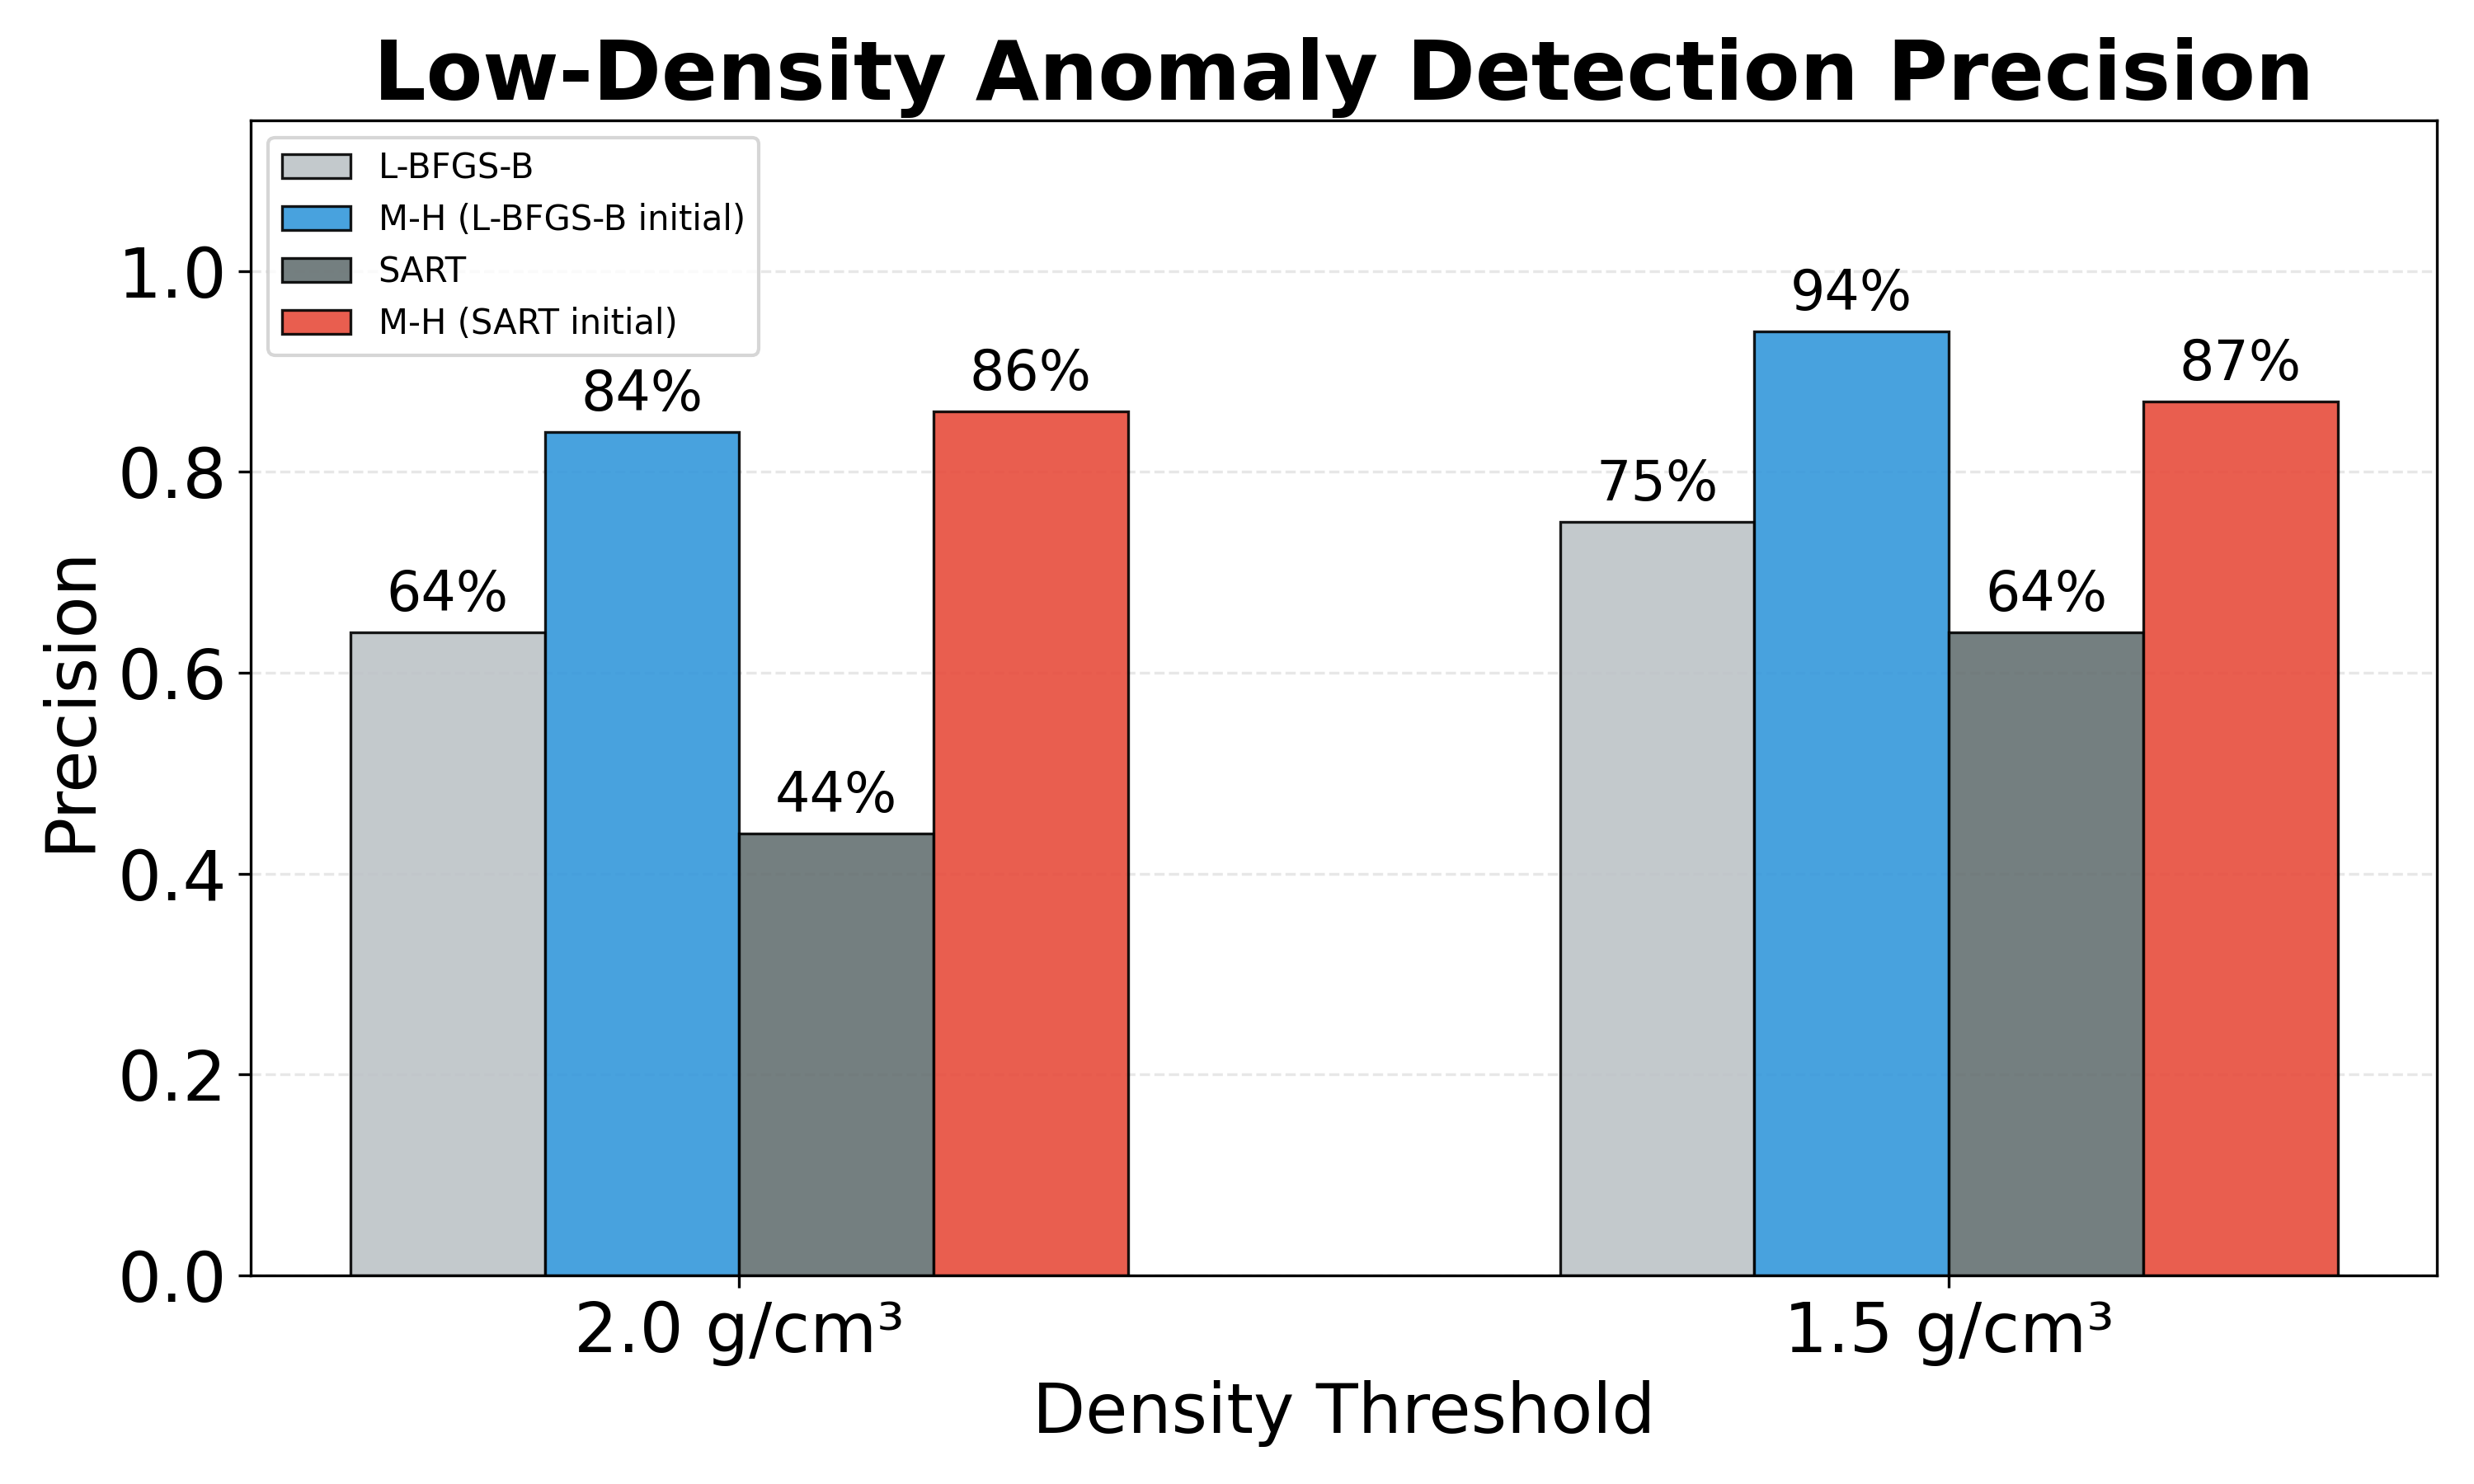

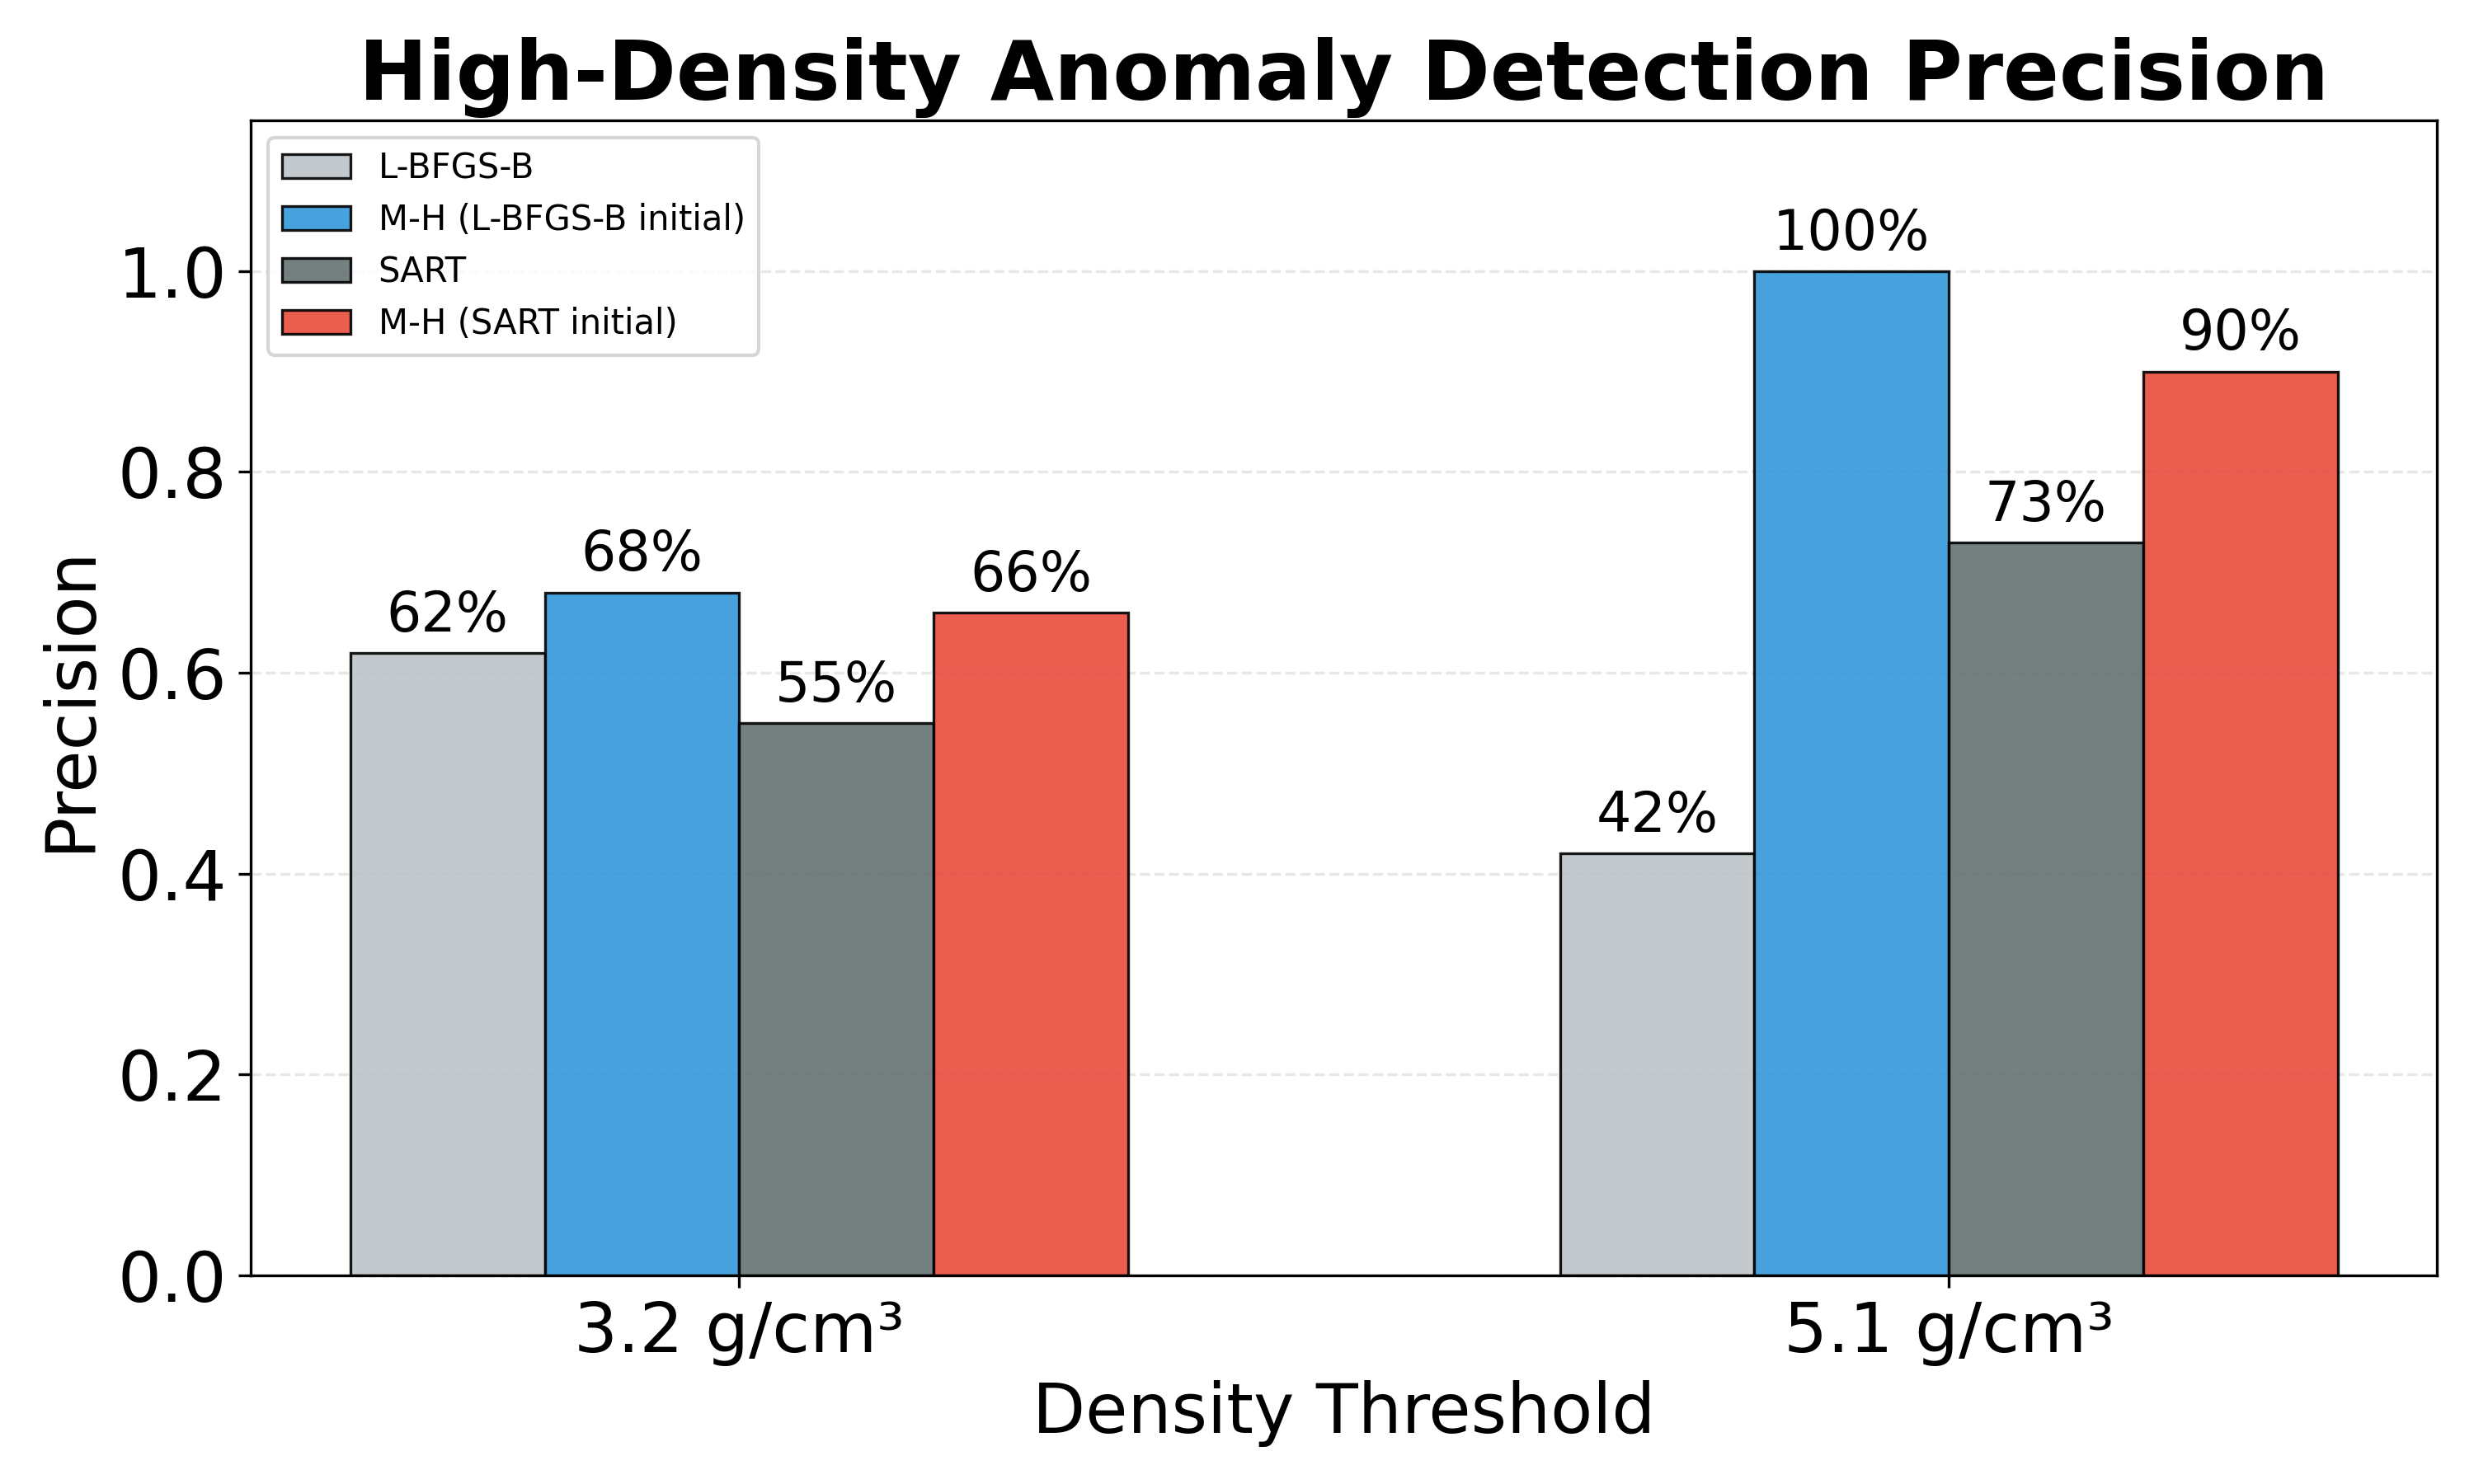

In [6]:
high_density_data = {
    'L-BFGS-B': [0.62, 0.42],
    'M-H (L-BFGS-B initial)': [0.68, 1.00],
    'SART': [0.55, 0.73],
    'M-H (SART initial)': [0.66, 0.90]
}

thresholds_high = ['3.2 g/cm³', '5.1 g/cm³']

fig1, ax1 = plot_precision_comparison(
    data=high_density_data,
    methods=list(high_density_data.keys()),
    thresholds=thresholds_high,
    title='High-Density Anomaly Detection Precision',
    xlabel='Density Threshold',
    ylabel='Precision',
    colors=['#BDC3C7', '#3498DB', "#657172", '#E74C3C'],  # Baseline gray, M-H blue/red
    font_family=None,
    bar_width=0.18,
    group_spacing=0.4,
    ylim=(0, 1.15),
    title_fontsize=24,
    tick_fontsize=20,
    label_fontsize=20,
    legend_fontsize=20,
    value_fontsize=16,
    legend_loc='upper left'
)
plt.savefig('output/SimBox/pic/high_density_precision_%.pdf', bbox_inches='tight')

# Low density anomaly data
low_density_data = {
    'L-BFGS-B': [0.64, 0.75],
    'M-H (L-BFGS-B initial)': [0.84, 0.94],
    'SART': [0.44, 0.64],
    'M-H (SART initial)': [0.86, 0.87]
}

thresholds_low = ['2.0 g/cm³', '1.5 g/cm³']

fig2, ax2 = plot_precision_comparison(
    data=low_density_data,
    methods=list(low_density_data.keys()),
    thresholds=thresholds_low,
    title='Low-Density Anomaly Detection Precision',
    xlabel='Density Threshold',
    ylabel='Precision',
    colors=['#BDC3C7', '#3498DB', '#657172', '#E74C3C'],
    font_family=None,
    bar_width=0.18,
    group_spacing=0.4,
    ylim=(0, 1.15),
    title_fontsize=24,
    tick_fontsize=20,
    label_fontsize=20,
    legend_fontsize=20,
    value_fontsize=16,
    legend_loc='upper left'
)
plt.savefig('output/SimBox/pic/low_density_precision_%.pdf', bbox_inches='tight')

plt.show()